 TASK 4: Sales Prediction using Python

● Predict future sales based on factors like advertising spend, target segment and platform.

● Prepare data through cleaning, transformation and feature selection.

● Use regression or time series models to forecast sales.

● Analyze how changes in advertising impact sales outcomes.

● Deliver actionable insights for business marketing strategies.

In [55]:
import pandas as pd

In [56]:
df =pd.read_csv("/content/Advertising.csv")

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


### Prepare data through cleaning, transformation and feature selection.

In [58]:
df.columns ### Data Cleaning

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [59]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)### Remove 'Unnnamed:0' column this not use for this dataset

In [60]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [61]:
df.head(5)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [62]:
df.isnull().sum() ### No Miss value in this dataset

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [63]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


Feature Selection

In [64]:
X = df[['TV', 'Radio', 'Newspaper']] ###input Variable
y = df['Sales'] ###Output Variable

In [65]:
from sklearn.preprocessing import StandardScaler

#Data Transformation (Scaling)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

In [67]:
from sklearn.linear_model import LinearRegression

### Regression Model
model = LinearRegression()

model.fit(X_train, y_train) # Train Model

LinearRegression()

In [68]:
 # Predictions

y_pred = model.predict(X_test)

In [69]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2_test = r2_score(y_test, y_pred)
r2_train = model.score(X_train, y_train)

print("Model Evaluation")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 test Score: {r2_test:.4f}")
print(f"R2 train Score: {r2_train:.4f}")

Model Evaluation
MAE : 1.4608
MSE : 3.1741
RMSE: 1.7816
R2 test Score: 0.8994
R2 train Score: 0.8957


In [70]:
 #Regression Coefficients

coefficients = pd.DataFrame({
    'Feature': ['TV', 'Radio', 'Newspaper'],
    'Coefficient': model.coef_
})

print("\nAdvertising Impact on Sales")
print(coefficients)



Advertising Impact on Sales
     Feature  Coefficient
0         TV     3.830606
1      Radio     2.801912
2  Newspaper     0.059983


In [71]:
#Actual vs Predicted Sales

results = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

print("\nActual vs Predicted")
print(results.head())


Actual vs Predicted
   Actual Sales  Predicted Sales
0          16.9        16.408024
1          22.4        20.889882
2          21.4        21.553843
3           7.3        10.608503
4          24.7        22.112373


###Visualization

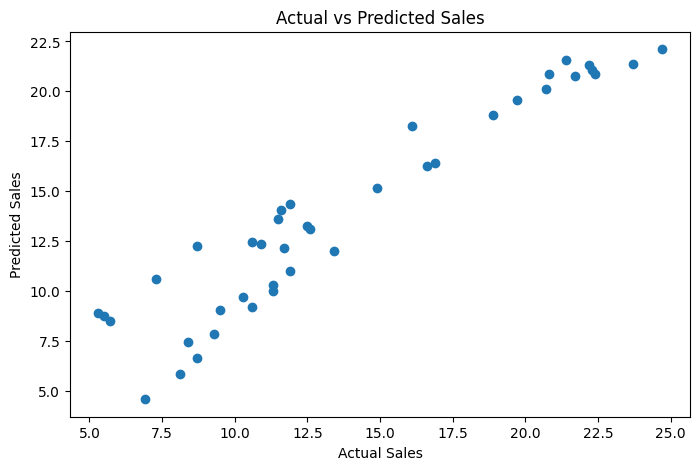

In [72]:
import matplotlib.pyplot as plt

# Scatter Plot
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [73]:

#Predict Future Sales

# Example:
# TV = 230
# Radio = 37
# Newspaper = 69

new_data = pd.DataFrame({
    'TV': [230],
    'Radio': [37],
    'Newspaper': [69]
})

# Scale new data
new_data_scaled = scaler.transform(new_data)

# Predict sales
future_sales = model.predict(new_data_scaled)

print("\nPredicted Future Sales:")
print("Estimated Sales =", future_sales[0])


Predicted Future Sales:
Estimated Sales = 20.45759025215365


### Create a Streamlit Application
We will write the app code to a file named `app.py` and then provide instructions on how to run it.

In [74]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Page config
st.set_page_config(page_title="Sales Predictor", layout="centered")

# Load data and train model (Simplified for the app)
@st.cache_data
def load_and_train():
    df = pd.read_csv("Advertising.csv")
    if 'Unnamed: 0' in df.columns:
        df.drop('Unnamed: 0', axis=1, inplace=True)

    X = df[['TV', 'Radio', 'Newspaper']]
    y = df['Sales']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = LinearRegression()
    model.fit(X_scaled, y)
    return scaler, model

scaler, model = load_and_train()

st.title("📈 Sales Prediction App")
st.write("Enter the advertising budget to forecast sales.")

# Input fields
tv = st.number_input("TV Advertising Budget", min_value=0.0, value=230.0)
radio = st.number_input("Radio Advertising Budget", min_value=0.0, value=37.0)
newspaper = st.number_input("Newspaper Advertising Budget", min_value=0.0, value=69.0)

if st.button("Predict Sales"):
    input_data = pd.DataFrame({'TV': [tv], 'Radio': [radio], 'Newspaper': [newspaper]})
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)

    st.success(f"### Estimated Sales: {prediction[0]:.2f} units")
    st.balloons()

Overwriting app.py


To run this app in Colab, you would typically use `localtunnel` or `ngrok`. First, install streamlit:
```bash
!pip install streamlit -q
```
Then run the app in the background:
```bash
!streamlit run app.py & npx localtunnel --port 8501
```

In [75]:
!pip install streamlit -q

In [78]:
!npm install -g localtunnel
import urllib
print("Password/Enpoint IP for localtunnel is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
changed 22 packages in 5s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏Password/Enpoint IP for localtunnel is: 34.106.153.238
⠙⠹⠸⠼⠴⠦⠧⠇

⠏⠋⠙⠹⠸your url is: https://cool-cougars-draw.loca.lt
2026-05-28 14:23:37.855 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.153.238:8501

  Stopping...
^C


In [79]:
!pip install pyngrok -q

KeyboardInterrupt: 

In [ ]:
from pyngrok import ngrok

# Configure ngrok with your authtoken
!ngrok config add-authtoken 3EM8PTswyqNJidr2RLhFKHHIyYY_26C85H23M9NZuDrZCeqR1

# Terminate open tunnels if any exist
ngrok.kill()

# Open a HTTP tunnel on port 8501
public_url = ngrok.connect(8501, "http")
print(f"Streamlit App URL: {public_url}")

In [ ]:
!streamlit run app.py

Business Insights

1. Higher TV and Radio advertising generally increase sales.
2. Newspaper advertising may have lower impact compared to TV and Radio.
3. Companies should focus more budget on high-performing platforms.
4. The regression model helps forecast future sales based on ad spend.